## Layyana Junaid 23k0056 Lab 6

In [2]:
import os, urllib.request
import numpy as np
import cv2
import pywt
import matplotlib.pyplot as plt

print("OpenCV:", cv2.__version__, "| SIFT available:", hasattr(cv2, "SIFT_create"))
os.makedirs("data", exist_ok=True)

OPENCV = "https://raw.githubusercontent.com/opencv/opencv/4.x/samples/data/"
EXTRA  = "https://raw.githubusercontent.com/opencv/opencv_extra/4.x/testdata/stitching/"
LANES  = "https://raw.githubusercontent.com/udacity/CarND-LaneLines-P1/master/test_images/"

DOWNLOADS = {
    "box.png":            OPENCV + "box.png",              # Task 2/4: reference object
    "box_in_scene.png":   OPENCV + "box_in_scene.png",     # Task 2/4: cluttered scene
    "lena.jpg":           OPENCV + "lena.jpg",             # Task 2: 'not in scene' check
    "smarties.png":       OPENCV + "smarties.png",         # Task 7: round objects
    "vtest.avi":          OPENCV + "vtest.avi",            # Task 8: pedestrians video
    "boat1.jpg":          EXTRA + "boat1.jpg",             # Task 5: overlapping shots
    "boat2.jpg":          EXTRA + "boat2.jpg",
    "boat3.jpg":          EXTRA + "boat3.jpg",
    "solidWhiteRight.jpg": LANES + "solidWhiteRight.jpg",  # Task 6: road
    "solidYellowCurve.jpg": LANES + "solidYellowCurve.jpg",
}
for name, url in DOWNLOADS.items():
    path = os.path.join("data", name)
    if not os.path.exists(path):
        urllib.request.urlretrieve(url, path)
print("Files in ./data:", sorted(os.listdir("data")))

def show(img, title="", figsize=(8, 5), cmap=None):
    plt.figure(figsize=figsize)
    if img.ndim == 2:
        plt.imshow(img, cmap=cmap or "gray")
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title); plt.axis("off"); plt.show()

def show_row(imgs, titles, figsize=(16, 5)):
    plt.figure(figsize=figsize)
    for i, (im, t) in enumerate(zip(imgs, titles), 1):
        plt.subplot(1, len(imgs), i)
        plt.imshow(im if im.ndim == 2 else cv2.cvtColor(im, cv2.COLOR_BGR2RGB),
                   cmap="gray" if im.ndim == 2 else None)
        plt.title(t); plt.axis("off")
    plt.tight_layout(); plt.show()

OpenCV: 4.13.0 | SIFT available: True
Files in ./data: ['boat1.jpg', 'boat2.jpg', 'boat3.jpg', 'box.png', 'box_in_scene.png', 'lena.jpg', 'smarties.png', 'solidWhiteRight.jpg', 'solidYellowCurve.jpg', 'vtest.avi']


In [3]:
# ---------- CONFIG: replace any path with your own file to use your own data ----------
CONFIG = {
    "lab_image":     None,                       # Task 1: photo of a computer lab (None = synthetic lab)
    "scene_image":   "data/box_in_scene.png",    # Task 2: lab scene to search
    "templates":     {"Computer box (asset A)": "data/box.png",
                      "Unrelated item (asset B)": "data/lena.jpg"},   # Task 2: inventory references
    "video_ref":     "data/box.png",             # Task 4: reference image of object
    "video_scene":   "data/box_in_scene.png",    # Task 4: used to synthesise a test video
    "video_path":    None,                       # Task 4: real video file (None = synthetic video)
    "pano_images":   ["data/boat1.jpg", "data/boat2.jpg", "data/boat3.jpg"],  # Task 5 (left to right)
    "lane_images":   ["data/solidWhiteRight.jpg", "data/solidYellowCurve.jpg"],  # Task 6
    "coin_image":    "data/smarties.png",        # Task 7 (swap for your own coins photo)
    "security_video": "data/vtest.avi",          # Task 8
}

### Task 1 – Computer Screen Detection (Hough Line Transform)

In [4]:
def make_synthetic_lab(rows=2, cols=4, seed=1):
    rng = np.random.default_rng(seed)
    H, W = 560, 1000
    img = np.full((H, W, 3), (170, 175, 170), np.uint8)
    states = {(0,1): "off", (1,2): "off", (1,0): "off"}   # which screens are switched off
    missing = {(1,3)}                                      # which monitor is missing
    mw, mh = 170, 120
    for r in range(rows):
        for c in range(cols):
            x = 60 + c * 235
            y = 60 + r * 250
            cv2.rectangle(img, (x-25, y+mh+70), (x+mw+25, y+mh+95), (90, 70, 50), -1)   # desk edge
            if (r, c) in missing:
                continue
            cv2.rectangle(img, (x, y), (x+mw, y+mh), (35, 35, 35), -1)                  # bezel
            on = states.get((r, c), "on") == "on"
            col = (225, 190, 110) if on else (12, 12, 12)
            cv2.rectangle(img, (x+10, y+10), (x+mw-10, y+mh-10), col, -1)               # screen
            cv2.rectangle(img, (x+mw//2-8, y+mh), (x+mw//2+8, y+mh+30), (60, 60, 60), -1)  # stand
    img = cv2.GaussianBlur(img, (3, 3), 0)
    noise = rng.normal(0, 2, img.shape)
    return np.clip(img + noise, 0, 255).astype(np.uint8)

def detect_screens(img, expected_rows=2, expected_cols=4):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (7, 7), 0)
    edges = cv2.Canny(blur, 40, 120)
    lines = cv2.HoughLinesP(edges, rho=1, theta=np.pi/180, threshold=50,
                            minLineLength=50, maxLineGap=15)
    mask = np.zeros_like(gray)
    hv = []
    if lines is not None:
        for x1, y1, x2, y2 in lines[:, 0]:
            ang = abs(np.degrees(np.arctan2(y2-y1, x2-x1)))
            if ang < 5 or ang > 175 or abs(ang-90) < 5:       # horizontal or vertical only
                cv2.line(mask, (x1, y1), (x2, y2), 255, 3)
                hv.append((x1, y1, x2, y2))
    mask = cv2.dilate(mask, np.ones((15, 15), np.uint8))
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = []
    for c in cnts:
        x, y, w, h = cv2.boundingRect(c)
        if 100 < w < 260 and 70 < h < 200 and 0.9 < w/h < 2.5:   # monitor-like size and aspect ratio
            boxes.append((x, y, w, h))
    return gray, edges, hv, boxes

img_lab = make_synthetic_lab() if CONFIG["lab_image"] is None else cv2.imread(CONFIG["lab_image"])
gray, edges, hv_lines, boxes = detect_screens(img_lab)
print(f"Hough segments kept (H/V): {len(hv_lines)} | candidate screens: {len(boxes)}")

Hough segments kept (H/V): 82 | candidate screens: 7


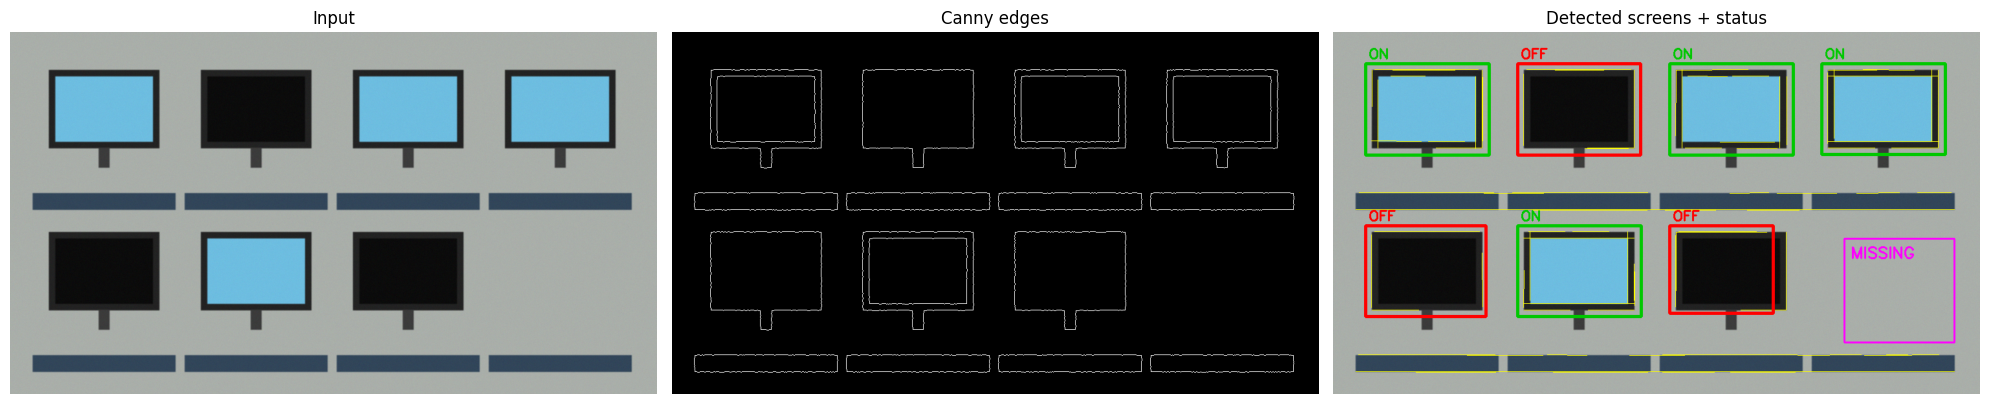

Row 1, Col 1: ON
Row 1, Col 2: OFF
Row 1, Col 3: ON
Row 1, Col 4: ON
Row 2, Col 1: OFF
Row 2, Col 2: ON
Row 2, Col 3: OFF
Row 2, Col 4: MISSING
Summary: {'ON': 4, 'OFF': 3, 'MISSING': 1}


In [5]:
EXPECTED_ROWS, EXPECTED_COLS = 2, 4      # set to your lab layout

out = img_lab.copy()
for (x1, y1, x2, y2) in hv_lines:
    cv2.line(out, (x1, y1), (x2, y2), (0, 255, 255), 1)

# group detected boxes into a grid
boxes = sorted(boxes, key=lambda b: (b[1], b[0]))
H, W = img_lab.shape[:2]
slot_w, slot_h = W / EXPECTED_COLS, H / EXPECTED_ROWS
grid = {}
for (x, y, w, h) in boxes:
    cx, cy = x + w/2, y + h/2
    grid[(int(cy // slot_h), int(cx // slot_w))] = (x, y, w, h)

report = []
for r in range(EXPECTED_ROWS):
    for c in range(EXPECTED_COLS):
        if (r, c) in grid:
            x, y, w, h = grid[(r, c)]
            inner = gray[y + h//4: y + 3*h//4, x + w//4: x + 3*w//4]
            on = inner.mean() > 80
            colr = (0, 200, 0) if on else (0, 0, 255)
            cv2.rectangle(out, (x, y), (x+w, y+h), colr, 3)
            cv2.putText(out, "ON" if on else "OFF", (x+5, y-8), cv2.FONT_HERSHEY_SIMPLEX, 0.7, colr, 2)
            report.append(((r, c), "ON" if on else "OFF"))
        else:
            sx, sy = int(c*slot_w + 40), int(r*slot_h + 40)
            cv2.rectangle(out, (sx, sy), (sx+int(slot_w)-80, sy+int(slot_h)-120), (255, 0, 255), 2)
            cv2.putText(out, "MISSING", (sx+10, sy+30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 255), 2)
            report.append(((r, c), "MISSING"))

show_row([img_lab, edges, out], ["Input", "Canny edges", "Detected screens + status"], figsize=(20, 5))
for (rc, st) in report:
    print(f"Row {rc[0]+1}, Col {rc[1]+1}: {st}")
print("Summary:", {s: sum(1 for _, x in report if x == s) for s in ("ON", "OFF", "MISSING")})


- `HoughLinesP` parameters: `threshold` = min votes, `minLineLength` rejects short edges (text, cables), `maxLineGap` bridges small breaks.
- ON/OFF is a brightness rule; for real photos calibrate the `80` threshold on your lighting.
- On a real photo, perspective makes screens trapezoids: relax the angle tolerance (e.g. 15°) or use `cv2.approxPolyDP` on the contours.

### Task 2 – Asset Tracking in a Computer Lab (SIFT)

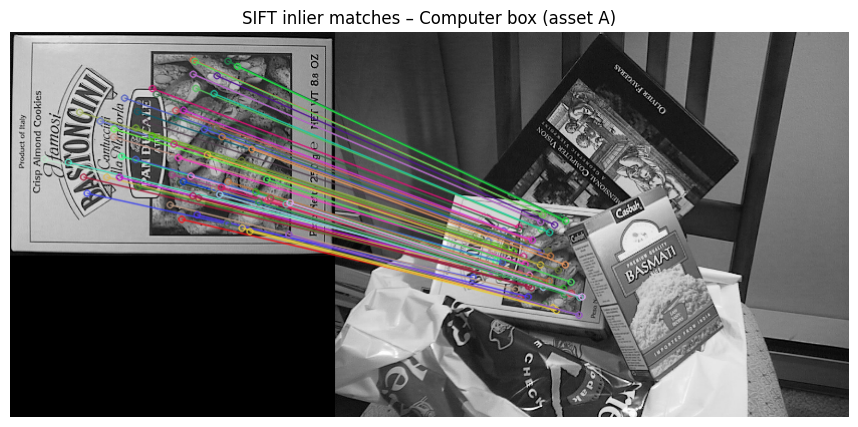

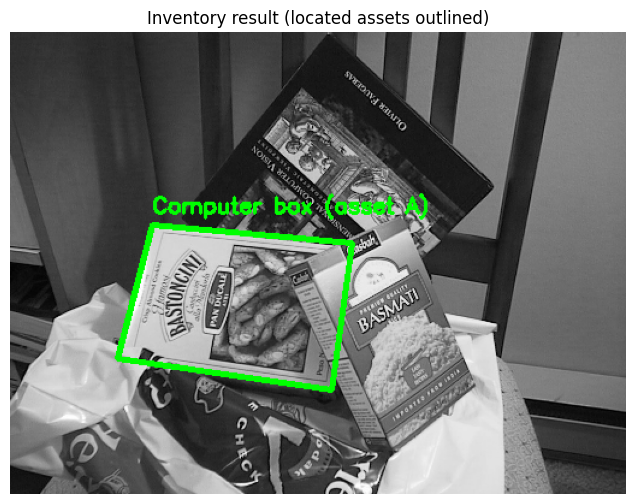

Asset                        Status      Good  Inliers
Computer box (asset A)       PRESENT       74       72
Unrelated item (asset B)     NOT FOUND      7        0


In [6]:
sift = cv2.SIFT_create()
flann = cv2.FlannBasedMatcher(dict(algorithm=1, trees=5), dict(checks=50))   # KD-tree for SIFT (float) descriptors

def locate(template_gray, scene_gray, ratio=0.7, min_inliers=10):
    kp1, d1 = sift.detectAndCompute(template_gray, None)
    kp2, d2 = sift.detectAndCompute(scene_gray, None)
    if d1 is None or d2 is None or len(kp1) < 2 or len(kp2) < 2:
        return None
    pairs = flann.knnMatch(d1, d2, k=2)
    good = [m for m, n in (p for p in pairs if len(p) == 2) if m.distance < ratio * n.distance]
    if len(good) < 4:
        return dict(found=False, good=len(good), inliers=0, kp1=kp1, kp2=kp2, matches=good, corners=None)
    src = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    H, inl = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
    n_in = int(inl.sum()) if inl is not None else 0
    corners = None
    if H is not None and n_in >= min_inliers:
        h, w = template_gray.shape
        box = np.float32([[0,0],[0,h-1],[w-1,h-1],[w-1,0]]).reshape(-1,1,2)
        corners = cv2.perspectiveTransform(box, H)
    return dict(found=corners is not None, good=len(good), inliers=n_in,
                kp1=kp1, kp2=kp2, matches=good, corners=corners, mask=inl)

scene = cv2.imread(CONFIG["scene_image"])
scene_gray = cv2.cvtColor(scene, cv2.COLOR_BGR2GRAY)
inventory, vis = [], scene.copy()
palette = [(0,255,0), (255,0,0), (0,165,255), (255,0,255)]

for i, (name, path) in enumerate(CONFIG["templates"].items()):
    tpl = cv2.imread(path)
    res = locate(cv2.cvtColor(tpl, cv2.COLOR_BGR2GRAY), scene_gray)
    inventory.append((name, res["found"], res["good"], res["inliers"]))
    if res["found"]:
        col = palette[i % len(palette)]
        cv2.polylines(vis, [np.int32(res["corners"])], True, col, 3)
        p = np.int32(res["corners"][0, 0])
        cv2.putText(vis, name, (p[0], max(p[1]-10, 15)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, col, 2)
        m = cv2.drawMatches(tpl, res["kp1"], scene, res["kp2"], res["matches"], None,
                            matchesMask=res["mask"].ravel().tolist(), flags=2)
        show(m, f"SIFT inlier matches – {name}", figsize=(14, 5))

show(vis, "Inventory result (located assets outlined)", figsize=(8, 6))
print(f"{'Asset':28s} {'Status':10s} {'Good':>5s} {'Inliers':>8s}")
for name, ok, g, n in inventory:
    print(f"{name:28s} {'PRESENT' if ok else 'NOT FOUND':10s} {g:5d} {n:8d}")

**Notes.** Ratio 0.7 trades recall for precision. For real labs, add one reference per component (keyboard, mouse, monitor, CPU) in `CONFIG["templates"]`; SIFT works best on textured objects (logos, labels) – plain black plastic has few keypoints.

### Task 3 – Anomaly Detection in Sensor Data (Wavelet Transform)

In [8]:
rng = np.random.default_rng(42)
n = 1000
t = np.arange(n)
baseline = 0.4 * np.sin(2*np.pi*t/250)
sensor = baseline + rng.normal(0, 0.5, n)

true_idx = rng.choice(np.arange(20, n-20), 25, replace=False)     # injected anomalies
sensor[true_idx] += rng.choice([-1, 1], 25) * rng.uniform(2.5, 4.0, 25)

def wavelet_denoise(x, wavelet="db4", level=5):
    coeffs = pywt.wavedec(x, wavelet, level=level)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    thr = sigma * np.sqrt(2 * np.log(len(x)))
    new = [coeffs[0]] + [pywt.threshold(c, thr, mode="soft") for c in coeffs[1:]]
    return pywt.waverec(new, wavelet)[:len(x)], sigma, thr

denoised, sigma, thr = wavelet_denoise(sensor)
residual = sensor - denoised

# robust anomaly threshold on the residual (MAD instead of std so anomalies don't inflate it)
mad_sigma = np.median(np.abs(residual - np.median(residual))) / 0.6745
anom_thr = 3 * mad_sigma
anom_idx = np.where(np.abs(residual) > anom_thr)[0]

print(f"noise sigma (wavelet) = {sigma:.3f} | universal threshold = {thr:.3f} | anomaly threshold = {anom_thr:.3f}")
print(f"Injected anomalies: {len(true_idx)} | flagged points: {len(anom_idx)}")
hit = len(set(true_idx) & set(anom_idx))
print(f"Injected anomalies recovered: {hit}/{len(true_idx)}  | extra flags (noise): {len(set(anom_idx) - set(true_idx))}")

noise sigma (wavelet) = 0.508 | universal threshold = 1.887 | anomaly threshold = 1.468
Injected anomalies: 25 | flagged points: 28
Injected anomalies recovered: 25/25  | extra flags (noise): 3


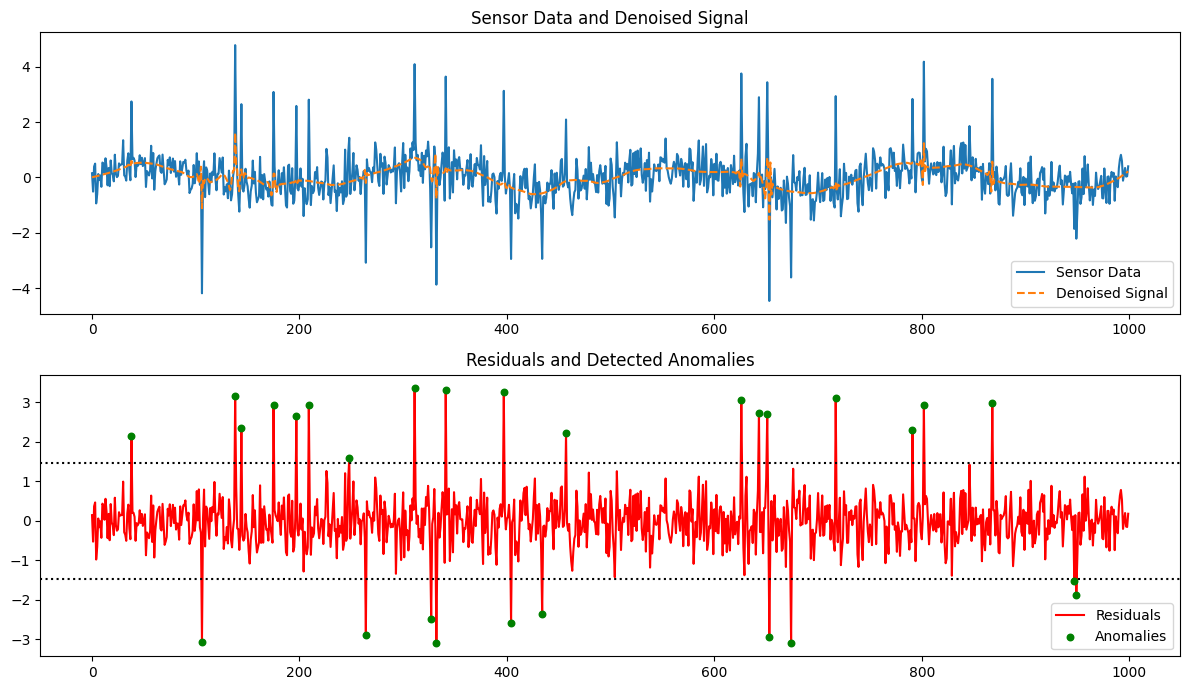

In [9]:
fig, ax = plt.subplots(2, 1, figsize=(12, 7))
ax[0].plot(sensor, label="Sensor Data")
ax[0].plot(denoised, "--", label="Denoised Signal")
ax[0].set_title("Sensor Data and Denoised Signal"); ax[0].legend(loc="lower right")

ax[1].plot(residual, "r", label="Residuals")
ax[1].scatter(anom_idx, residual[anom_idx], c="green", s=22, zorder=3, label="Anomalies")
ax[1].axhline(anom_thr, ls=":", c="k"); ax[1].axhline(-anom_thr, ls=":", c="k")
ax[1].set_title("Residuals and Detected Anomalies"); ax[1].legend(loc="lower right")
plt.tight_layout(); plt.show()

**Notes.** Using MAD instead of the standard deviation matters: spikes inflate the std and would hide themselves. In a real-time system you would run this on a sliding window (e.g. last 256 samples) – the same code applies per window.

### Task 4 – Object Recognition in Video (SIFT)

Object recognised in 60/60 frames


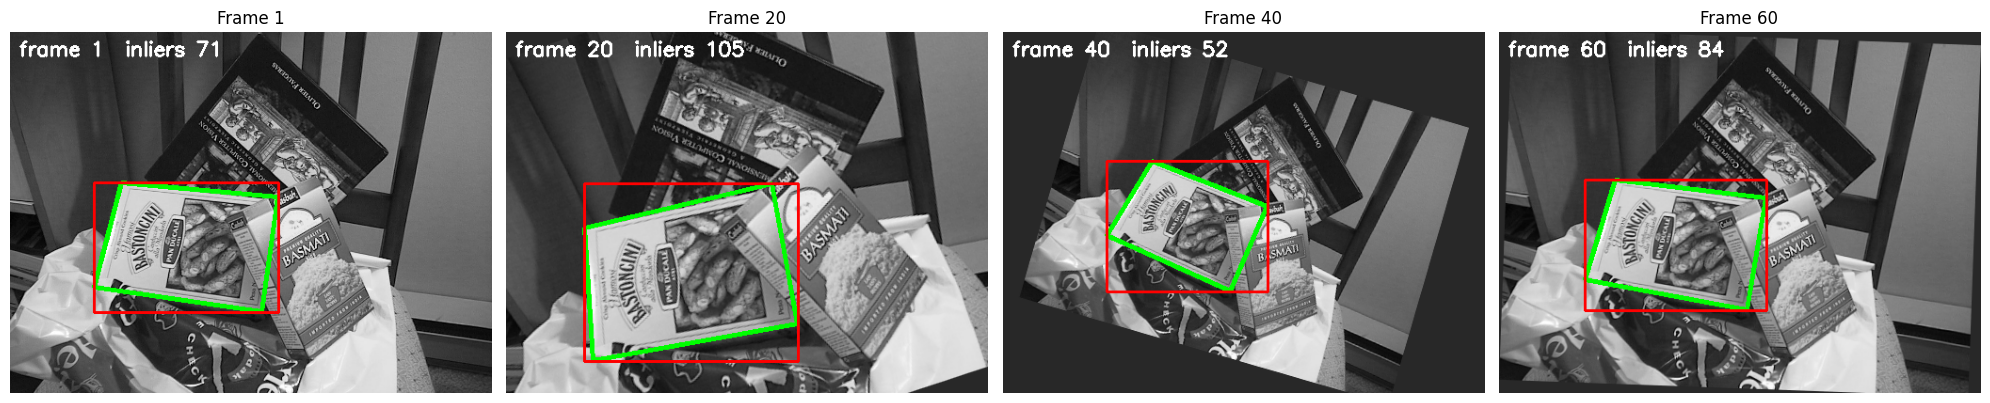

Saved task4_output.mp4


In [10]:
def synth_video(scene_bgr, n=60):
    h, w = scene_bgr.shape[:2]
    frames = []
    for i in range(n):
        s = 1.0 + 0.25*np.sin(2*np.pi*i/n)            # scale change
        a = 20*np.sin(2*np.pi*i/n)                     # rotation (deg)
        M = cv2.getRotationMatrix2D((w/2, h/2), a, s)
        f = cv2.warpAffine(scene_bgr, M, (w, h), borderValue=(40, 40, 40))
        if 20 <= i < 35:                               # partial occlusion
            x0 = int(w*0.35 + (i-20)*6)
            cv2.rectangle(f, (x0, int(h*0.35)), (x0+70, int(h*0.75)), (30, 30, 30), -1)
        frames.append(f)
    return frames

def frame_source():
    if CONFIG["video_path"] is None:
        for f in synth_video(cv2.imread(CONFIG["video_scene"])): yield f
    else:
        cap = cv2.VideoCapture(CONFIG["video_path"])
        while True:
            ok, f = cap.read()
            if not ok: break
            yield f
        cap.release()

ref = cv2.imread(CONFIG["video_ref"], cv2.IMREAD_GRAYSCALE)
kp_ref, des_ref = sift.detectAndCompute(ref, None)        # computed ONCE
hr, wr = ref.shape
ref_box = np.float32([[0,0],[0,hr-1],[wr-1,hr-1],[wr-1,0]]).reshape(-1,1,2)

results, found_count, total = [], 0, 0
for frame in frame_source():
    total += 1
    g = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    kp, des = sift.detectAndCompute(g, None)
    vis, inl_n = frame.copy(), 0
    if des is not None and len(kp) > 4:
        pairs = flann.knnMatch(des_ref, des, k=2)
        good = [m for m, n in (p for p in pairs if len(p) == 2) if m.distance < 0.7*n.distance]
        if len(good) >= 8:
            src = np.float32([kp_ref[m.queryIdx].pt for m in good]).reshape(-1,1,2)
            dst = np.float32([kp[m.trainIdx].pt for m in good]).reshape(-1,1,2)
            H, inl = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
            inl_n = int(inl.sum()) if inl is not None else 0
            if H is not None and inl_n >= 10:
                quad = cv2.perspectiveTransform(ref_box, H)
                x, y, w, h = cv2.boundingRect(np.int32(quad))
                cv2.polylines(vis, [np.int32(quad)], True, (0, 255, 0), 3)
                cv2.rectangle(vis, (x, y), (x+w, y+h), (0, 0, 255), 2)
                found_count += 1
    cv2.putText(vis, f"frame {total}  inliers {inl_n}", (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2)
    results.append(vis)

print(f"Object recognised in {found_count}/{total} frames")
idx = np.linspace(0, len(results)-1, 4, dtype=int)
show_row([results[i] for i in idx], [f"Frame {i+1}" for i in idx], figsize=(20, 5))

# save annotated video (download from the Files panel in Colab)
hh, ww = results[0].shape[:2]
vw = cv2.VideoWriter("task4_output.mp4", cv2.VideoWriter_fourcc(*"mp4v"), 20, (ww, hh))
for f in results: vw.write(f)
vw.release()
print("Saved task4_output.mp4")

**Notes.** Green quad = the projected reference outline (handles rotation/perspective); red = axis-aligned bounding box. During occlusion fewer features match, so inliers drop – the threshold of 10 inliers decides when we stop claiming a detection.

### Task 5 – Panoramic Image (SIFT + Homography)


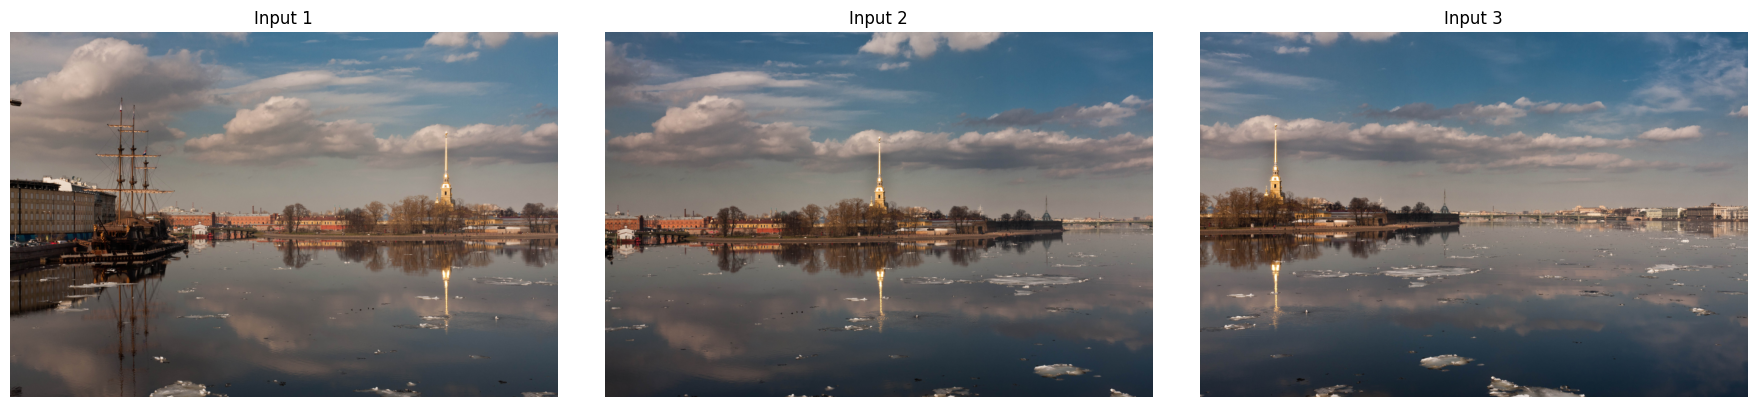

Stitched image 2: RANSAC inliers = 425
Stitched image 3: RANSAC inliers = 316


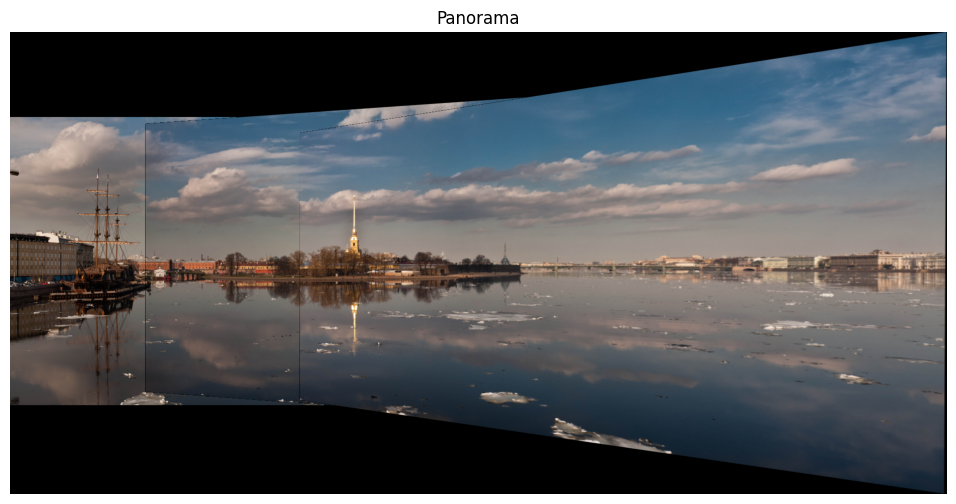

True

In [11]:
def load_resized(path, width=900):
    im = cv2.imread(path)
    s = width / im.shape[1]
    return cv2.resize(im, None, fx=s, fy=s, interpolation=cv2.INTER_AREA)

def stitch_pair(base, new, ratio=0.75):
    g1, g2 = cv2.cvtColor(base, cv2.COLOR_BGR2GRAY), cv2.cvtColor(new, cv2.COLOR_BGR2GRAY)
    k1, d1 = sift.detectAndCompute(g1, None)
    k2, d2 = sift.detectAndCompute(g2, None)
    bf = cv2.BFMatcher()
    good = [m for m, n in bf.knnMatch(d2, d1, k=2) if m.distance < ratio * n.distance]
    if len(good) < 10:
        raise RuntimeError(f"Not enough matches ({len(good)}) - are the images overlapping/ordered?")
    src = np.float32([k2[m.queryIdx].pt for m in good]).reshape(-1,1,2)    # new
    dst = np.float32([k1[m.trainIdx].pt for m in good]).reshape(-1,1,2)    # base
    H, mask = cv2.findHomography(src, dst, cv2.RANSAC, 4.0)

    h1, w1 = base.shape[:2]; h2, w2 = new.shape[:2]
    corners_new = cv2.perspectiveTransform(np.float32([[0,0],[0,h2],[w2,h2],[w2,0]]).reshape(-1,1,2), H)
    corners_all = np.vstack([corners_new, np.float32([[0,0],[0,h1],[w1,h1],[w1,0]]).reshape(-1,1,2)])
    xmin, ymin = np.int32(corners_all.min(axis=0).ravel() - 0.5)
    xmax, ymax = np.int32(corners_all.max(axis=0).ravel() + 0.5)
    T = np.array([[1,0,-xmin],[0,1,-ymin],[0,0,1]], dtype=np.float64)

    canvas = cv2.warpPerspective(new, T @ H, (xmax-xmin, ymax-ymin))
    region = canvas[-ymin:h1-ymin, -xmin:w1-xmin]
    empty = region.sum(axis=2) == 0                       # keep warped pixels where both overlap
    region[empty] = base[empty]
    canvas[-ymin:h1-ymin, -xmin:w1-xmin] = region
    return canvas, int(mask.sum()), (k1, k2, good, mask)

def crop_black(img):
    g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    ys, xs = np.where(g > 0)
    return img[ys.min():ys.max()+1, xs.min():xs.max()+1]

imgs = [load_resized(p) for p in CONFIG["pano_images"]]
show_row(imgs, [f"Input {i+1}" for i in range(len(imgs))], figsize=(18, 4))

pano = imgs[0]
for i, nxt in enumerate(imgs[1:], 2):
    pano, n_inl, _ = stitch_pair(pano, nxt)
    print(f"Stitched image {i}: RANSAC inliers = {n_inl}")
show(crop_black(pano), "Panorama", figsize=(16, 6))
cv2.imwrite("task5_panorama.jpg", crop_black(pano))

**Notes.** Images must be given in left-to-right order with ~30-40% overlap, and the camera should rotate about its centre (not translate) for a homography to be valid. Seams are not blended here; for production quality use multi-band blending (`cv2.Stitcher_create()` does this automatically and is a good comparison).

### Task 6 – Lane Detection (Hough Line Transform)


solidWhiteRight.jpg: left segments = 4, right segments = 5


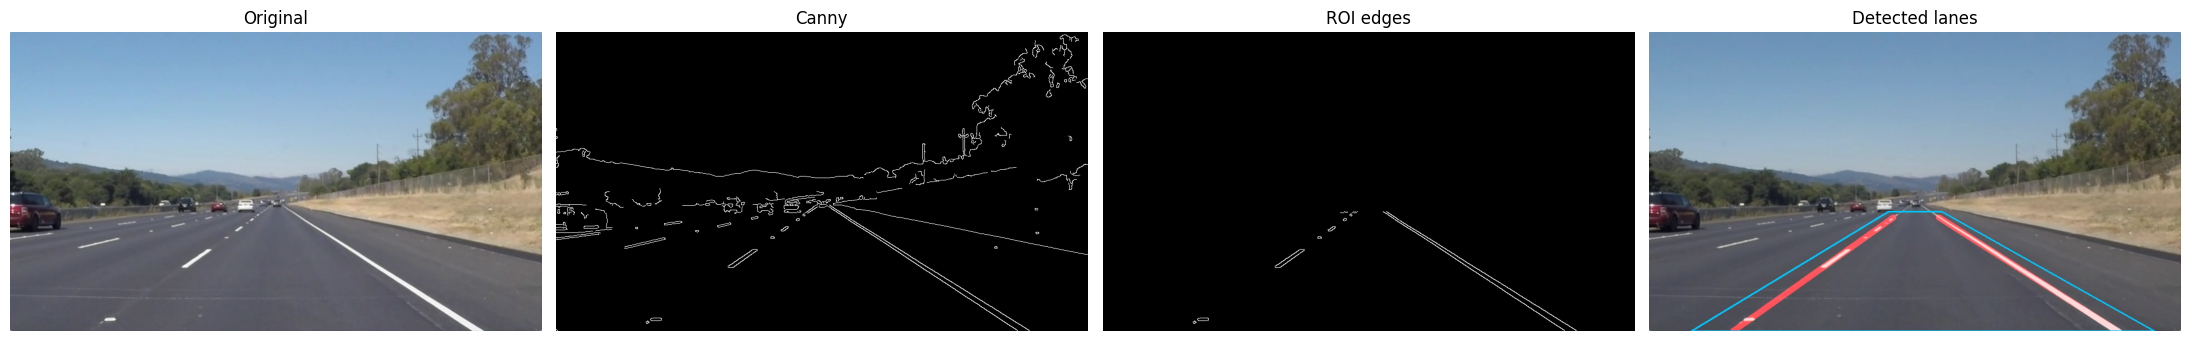

solidYellowCurve.jpg: left segments = 5, right segments = 5


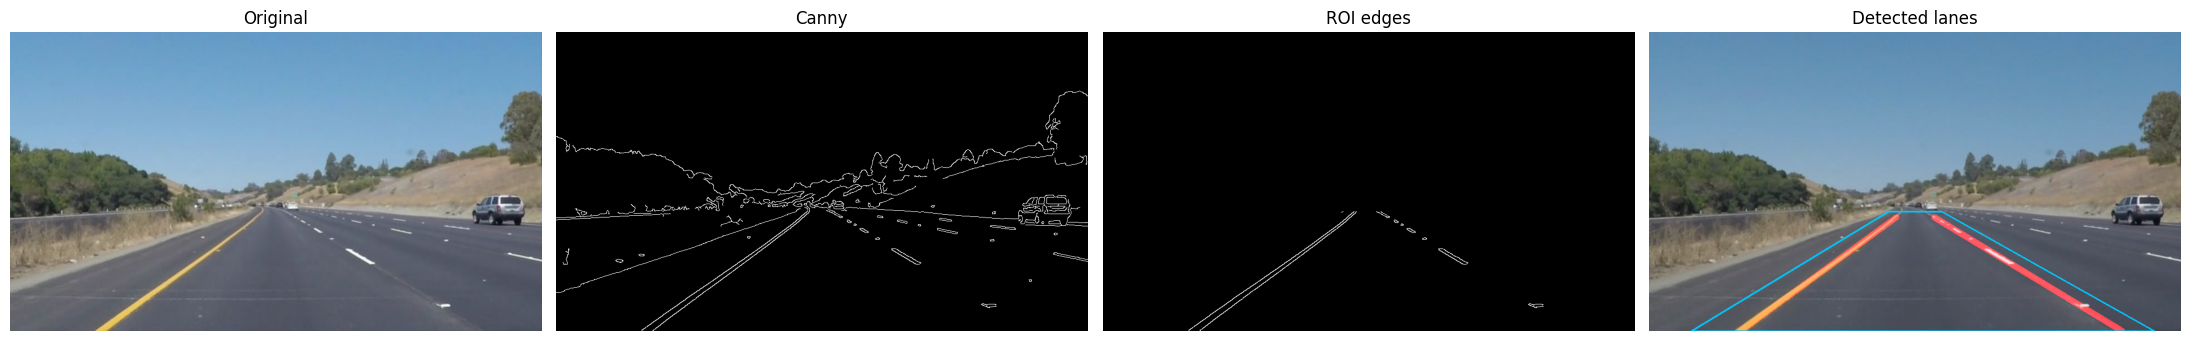

In [12]:
def region_of_interest(edges):
    h, w = edges.shape
    poly = np.array([[(int(0.08*w), h), (int(0.45*w), int(0.60*h)),
                      (int(0.55*w), int(0.60*h)), (int(0.95*w), h)]], np.int32)
    mask = np.zeros_like(edges)
    cv2.fillPoly(mask, poly, 255)
    return cv2.bitwise_and(edges, mask), poly

def lane_lines(img):
    h, w = img.shape[:2]
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(cv2.GaussianBlur(gray, (5, 5), 0), 50, 150)
    roi, poly = region_of_interest(edges)
    segs = cv2.HoughLinesP(roi, 1, np.pi/180, threshold=30, minLineLength=40, maxLineGap=100)
    left, right = [], []
    if segs is not None:
        for x1, y1, x2, y2 in segs[:, 0]:
            if x2 == x1: continue
            m = (y2-y1) / (x2-x1)
            if abs(m) < 0.4: continue                       # drop near-horizontal
            b = y1 - m*x1
            (left if m < 0 else right).append((m, b, np.hypot(x2-x1, y2-y1)))
    out = img.copy()
    overlay = np.zeros_like(img)
    y_bot, y_top = h, int(0.62*h)
    for side, color in ((left, (0, 0, 255)), (right, (0, 0, 255))):
        if not side: continue
        arr = np.array(side)
        m = np.average(arr[:, 0], weights=arr[:, 2])        # length-weighted average
        b = np.average(arr[:, 1], weights=arr[:, 2])
        x_bot, x_top = int((y_bot-b)/m), int((y_top-b)/m)
        cv2.line(overlay, (x_bot, y_bot), (x_top, y_top), color, 10)
    out = cv2.addWeighted(out, 0.9, overlay, 1.0, 0)
    cv2.polylines(out, poly, True, (255, 200, 0), 2)
    return edges, roi, out, len(left), len(right)

for p in CONFIG["lane_images"]:
    img = cv2.imread(p)
    edges, roi, res, nl, nr = lane_lines(img)
    print(f"{os.path.basename(p)}: left segments = {nl}, right segments = {nr}")
    show_row([img, edges, roi, res], ["Original", "Canny", "ROI edges", "Detected lanes"], figsize=(22, 4))

**Notes.** The trapezoid ROI is tuned for a forward-facing dashcam; change its corner ratios for your camera. Straight-line Hough fails on sharp curves – a polynomial fit on the segment endpoints is the usual next step.

### Task 7 – Coin Detection and Counting (Hough Circle Transform)


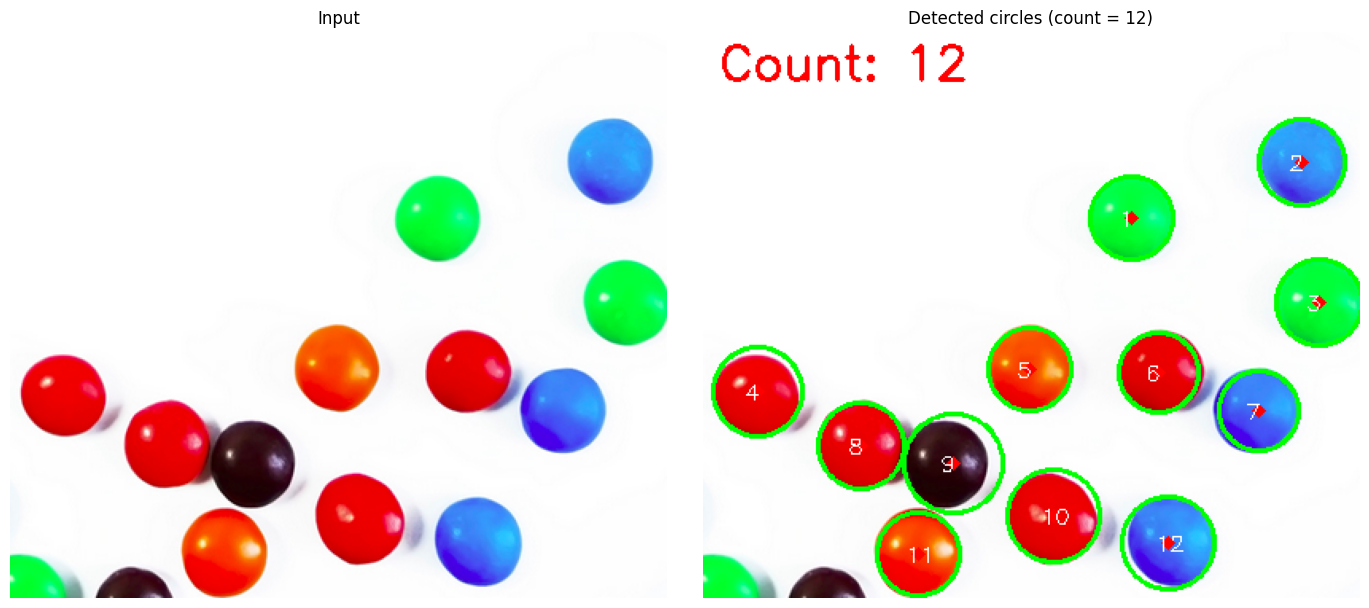

Detected radii (px): [25, 25, 26, 26, 26, 27, 27, 27, 28, 29, 29, 31]


In [13]:
img = cv2.imread(CONFIG["coin_image"])
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_blur = cv2.medianBlur(gray, 5)          # median blur reduces noise but keeps edges

circles = cv2.HoughCircles(gray_blur, cv2.HOUGH_GRADIENT, dp=1.2, minDist=gray.shape[0]/16,
                           param1=100, param2=30, minRadius=10, maxRadius=60)
out = img.copy()
count = 0
if circles is not None:
    circles = np.round(circles[0]).astype(int)
    for i, (x, y, r) in enumerate(sorted(circles.tolist(), key=lambda c: (c[1]//40, c[0])), 1):
        cv2.circle(out, (x, y), r, (0, 255, 0), 2)
        cv2.circle(out, (x, y), 2, (0, 0, 255), 3)
        cv2.putText(out, str(i), (x-8, y+5), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1)
    count = len(circles)
cv2.putText(out, f"Count: {count}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
show_row([img, out], ["Input", f"Detected circles (count = {count})"], figsize=(14, 6))
print("Detected radii (px):", sorted(circles[:, 2].tolist()) if circles is not None else [])

**Notes.** If you see missed coins, lower `param2`; if you see ghost circles, raise it. For coins of different denominations you can additionally group detections by radius (e.g. k-means on `r`) to get a per-denomination count.

### Task 8 – Smart Security System (Boundary Detection + Alarm)


Video: 768 x 576 | frames: 795
Processed 795 frames | alarm triggered in 219 frames. Saved task8_output.mp4


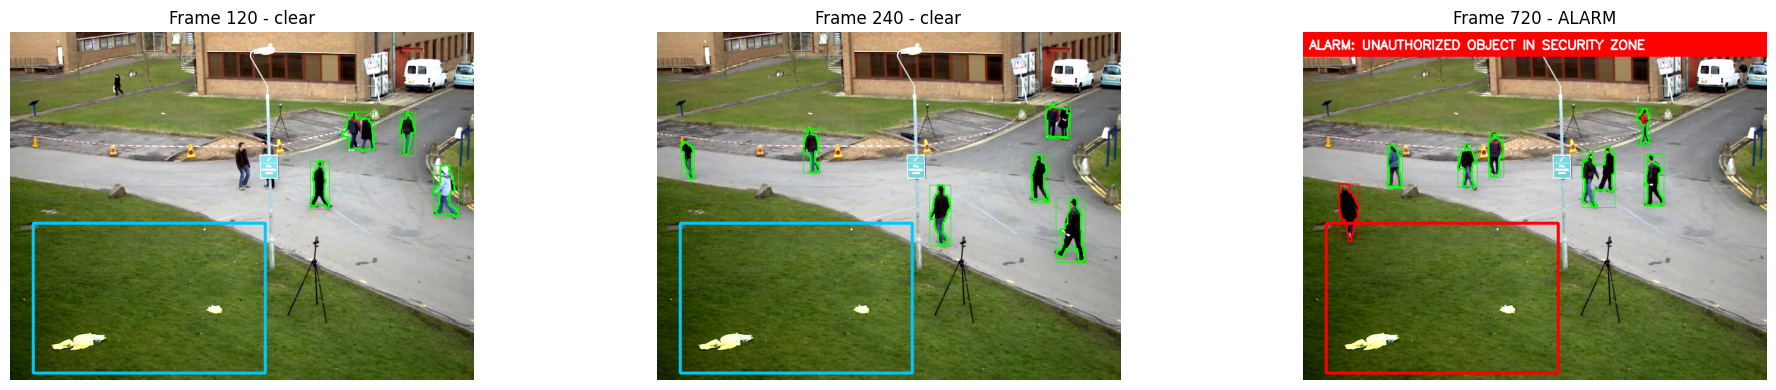

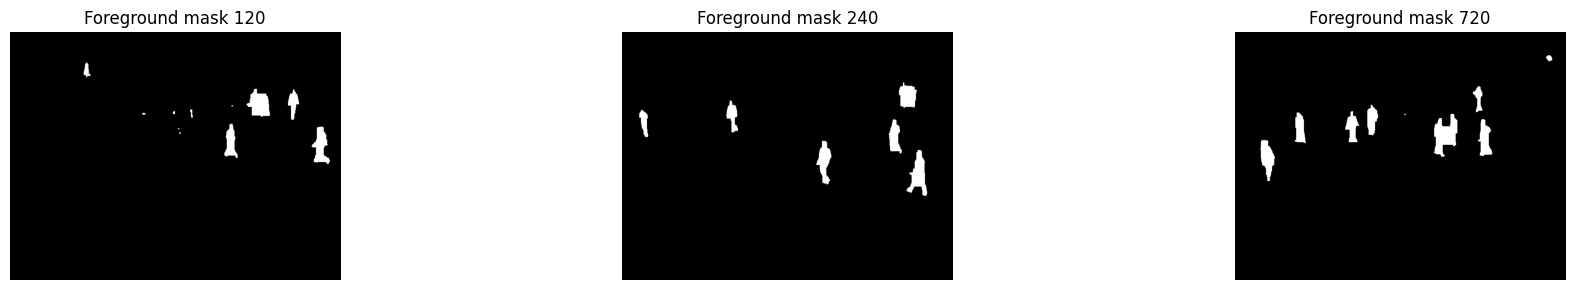

In [14]:
cap = cv2.VideoCapture(CONFIG["security_video"])
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)); H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print("Video:", W, "x", H, "| frames:", int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))

# security zone polygon (fractions of frame size) - edit to your scene
zone = np.array([[0.05, 0.55], [0.55, 0.55], [0.55, 0.98], [0.05, 0.98]]) * [W, H]
zone = zone.astype(np.int32)

bg = cv2.createBackgroundSubtractorMOG2(history=300, varThreshold=40, detectShadows=True)
kernel = np.ones((3, 3), np.uint8)

saved, alarm_frames, n = [], 0, 0
out_vid = cv2.VideoWriter("task8_output.mp4", cv2.VideoWriter_fourcc(*"mp4v"), 20, (W, H))
while True:
    ok, frame = cap.read()
    if not ok: break
    n += 1
    fg = bg.apply(frame)
    fg = cv2.threshold(fg, 200, 255, cv2.THRESH_BINARY)[1]            # drop shadows (value 127)
    fg = cv2.morphologyEx(fg, cv2.MORPH_OPEN, kernel, iterations=1)
    fg = cv2.morphologyEx(fg, cv2.MORPH_CLOSE, np.ones((9, 9), np.uint8), iterations=2)
    cnts, _ = cv2.findContours(fg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    vis = frame.copy()
    intruder = False
    for c in cnts:
        if cv2.contourArea(c) < 600: continue
        x, y, w, h = cv2.boundingRect(c)
        foot = (x + w//2, y + h)
        inside = cv2.pointPolygonTest(zone, foot, False) >= 0
        color = (0, 0, 255) if inside else (0, 255, 0)
        cv2.drawContours(vis, [c], -1, color, 2)                      # object boundary
        cv2.rectangle(vis, (x, y), (x+w, y+h), color, 1)
        intruder |= inside
    cv2.polylines(vis, [zone], True, (0, 0, 255) if intruder else (255, 200, 0), 3)
    if intruder:
        alarm_frames += 1
        cv2.rectangle(vis, (0, 0), (W, 40), (0, 0, 255), -1)
        cv2.putText(vis, "ALARM: UNAUTHORIZED OBJECT IN SECURITY ZONE", (10, 28),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    out_vid.write(vis)
    if n % 120 == 0 or (intruder and len(saved) < 3 and n % 20 == 0):
        saved.append((n, vis, fg, intruder))
cap.release(); out_vid.release()
print(f"Processed {n} frames | alarm triggered in {alarm_frames} frames. Saved task8_output.mp4")

# display a few frames: one safe frame + frames with alarm
safe = [s for s in saved if not s[3]][:2]
alarm = [s for s in saved if s[3]][:2]
sel = (safe + alarm)[:4]
show_row([s[1] for s in sel], [f"Frame {s[0]} - " + ("ALARM" if s[3] else "clear") for s in sel], figsize=(20, 4))
show_row([s[2] for s in sel], [f"Foreground mask {s[0]}" for s in sel], figsize=(20, 3))

**Notes.** MOG2 learns the static background, so anything new/moving becomes foreground. For "unauthorised *objects*" left behind (not moving), keep a longer-term background model or compare against a reference empty-zone image with `cv2.absdiff`. Replace `CONFIG["security_video"]` with `0` for a live webcam (local machine only).